In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np
import pickle
import datetime

from datetime import datetime
from dateutil import parser
from datetime import datetime, timedelta
from scipy.optimize import minimize_scalar




In [2]:
reference_time = datetime(1970, 1, 1, 0, 0, 0)

In [3]:
ls ../Results/firstResults/

Nightwatch/            Selenium/              idle/
Playwright/            empty                  initial/
Puppeteer/             energy_calculated.csv  temperatures.csv


In [4]:
# import power measurements

# spike er færdig ved time = 100
# mellemrum mellem iterationer står i filnavnet (Selenium = 60)
# mellemrum mellem hver kørsel 120 sek
# actions: Nightwatch, Playwright, Cypress = 8 actions
# actions: Selenium = 13 actions Noget i denne retning: 1,2,2,2,2,3,4,5,6,6,6,6,7,8
# Updated actions: SE
# actions: Puppeteer = 7 actions
dict_Nightwatch = {  'id':'Nightwatch',
                     'name':'Nightwatch',
                     'filepath': '../Results/firstResults/idle/Nightwatch/idle_nightwatch_10sek_35rep.csv',
                     'logpath':'../Results/firstResults/idle/Nightwatch/LOGFILE',
                     'spike done':100,
                     'waiting_between_iterations':120,
                     'waiting_between_runs':300,
                     'actions':8,
                     'action order': ['refresh','left click','right click','double click','checkbox','drag & drop', 'input text','scroll'],
                     'action repetition': {'refresh':140,'left click':350,'right click':170,'double click':160,'checkbox':120,'drag & drop':60, 'input text':60,'scroll':60},
                     'minimum iteration time': 10,
                     'repetitions in an iteration':35,
                     'time_after_script_before_fib': 30,
                     'time_after_fib_before_run': 120
                  }
dict_Playwright = {  'id':'Playwright',
                     'name':'Playwright',
                     'filepath':'../Results/firstResults/idle/Playwright/idle_playwright_10sek_35rep.csv',
                     'logpath':'../Results/firstResults/idle/Playwright/LOGFILE',
                     'spike done':100,
                     'waiting_between_iterations':120,
                     'waiting_between_runs':300,
                     'actions':8,
                     'action order': ['refresh','left click','right click','double click','checkbox','drag & drop', 'input text','scroll'],
                     'action repetition': {'refresh':140,'left click':350,'right click':170,'double click':160,'checkbox':120,'drag & drop':60, 'input text':60,'scroll':60},
                     'minimum iteration time': 10,
                     'repetitions in an iteration':35,
                     'time_after_script_before_fib': 30,
                     'time_after_fib_before_run': 120
                  }
dict_Puppeteer   = { 'id':'Puppeteer',
                     'name':'Puppeteer',
                     'filepath':'../Results/firstResults/idle/Puppeteer/idle_puppeteer_10sek_35rep.csv',
                     'logpath':'../Results/firstResults/idle/Playwright/LOGFILE',
                     'spike done':100,
                     'waiting_between_iterations':300,
                     'waiting_between_runs':600,
                     'actions':7,
                     'action order': ['refresh','left click','right click','double click','checkbox','input text', 'scroll'],
                     'action repetition': {'refresh':140,'left click':350,'right click':170,'double click':160,'checkbox':120,'drag & drop':60, 'input text':60,'scroll':60},
                     'minimum iteration time': 10,
                     'repetitions in an iteration':35,
                     'time_after_script_before_fib': 30,
                     'time_after_fib_before_run': 450 
                  }


dict_Selenium  = {   'id':'Selenium',
                     'name':'Selenium',
                     'filepath':'../Results/firstResults/idle/Selenium/idle_selenium_10sek_35rep.csv',
                     'logpath':'../Results/firstResults/idle/Playwright/LOGFILE',
                     'spike done':100,
                     'waiting_between_iterations':120,
                     'waiting_between_runs':300,
                     'actions':13,
                     'action order': ['refresh with clear','refresh','left click with clear and no action api','left click','left click with action api','right click', 'double click', 'checkbox', 'drag & drop', 'input text, no backspaces', 'input text, with backspace, no clear', 'input text', 'scroll'],
                     'action repetition': {'refresh with clear':140,'refresh':140,'left click with clear and no action api':350,'left click':350, 'left click with action api':350,'right click':170,'double click':160,'checkbox':120,'drag & drop':60,'input text, no backspaces':60,'input text, with backspace, no clear':60,'input text':60,'scroll':60},
                     'minimum iteration time': 10,
                     'repetitions in an iteration':35,
                     'time_after_script_before_fib': 30,
                     'time_after_fib_before_run': 120
                  }
# 'action order': ['refresh with clear','refresh','left click with clear and no action api','left click with no action api','left click','right click', 'double click', 'checkbox', 'drag & drop', 'input text, no backspaces', 'input text, with backspace, no clear', 'input text', 'scroll'],


all_dicts = {
    dict_Nightwatch['id']:dict_Nightwatch,
    dict_Playwright['id']:dict_Playwright,
    dict_Puppeteer['id']:dict_Puppeteer,
    dict_Selenium['id']:dict_Selenium}



In [5]:
# import power measurements

# spike er færdig ved time = 100
# mellemrum mellem iterationer står i filnavnet (Selenium = 60)
# mellemrum mellem hver kørsel 120 sek
# actions: Nightwatch, Playwright, Cypress = 8 actions
# actions: Selenium = 13 actions Noget i denne retning: 1,2,2,2,2,3,4,5,6,6,6,6,7,8
# Updated actions: SE
# actions: Puppeteer = 7 actions
# dict_Nightwatch = {  'id':'Nightwatch',
#                      'name':'Nightwatch',
#                      'filepath': '../Results/firstResults/Nightwatch/nightwatch_1_to_8_30_120_120_300.csv',
#                      'logpath':'../Results/firstResults/Nightwatch/LOGFILE',
#                      'spike done':100,
#                      'waiting_between_iterations':60,
#                      'waiting_between_runs':120,
#                      'actions':8,
#                      'action order': ['action 1','action 2','action 3','action 4','action 5','action 6', 'action 7','action 8'],
#                      'minimum iteration time': 10,
#                      'repetitions in an iteration':35,
#                      'time_after_script_before_fib': 30,
#                      'time_after_fib_before_run': 120
#                   }
# dict_Playwright = {  'id':'Playwright',
#                      'name':'Playwright',
#                      'filepath':'../Results/firstResults/Playwright/Playwright_1_to_8_30_120_120_300.csv',
#                      'logpath':'../Results/firstResults/Playwright/LOGFILE',
#                      'spike done':100,
#                      'waiting_between_iterations':120,
#                      'waiting_between_runs':240,
#                      'actions':8,
#                      'action order': ['action 1','action 2','action 3','action 4','action 5','action 6', 'action 7','action 8'],
#                      'minimum iteration time': 10,
#                      'repetitions in an iteration':35,
#                      'time_after_script_before_fib': 30,
#                      'time_after_fib_before_run': 120
#                   }
# dict_Puppeteer   = { 'id':'Puppeteer',
#                      'name':'Puppeteer',
#                      'filepath':'../Results/firstResults/Puppeteer/puppeteer_1_to_8_30_450_300_600.csv',
#                      'logpath':'../Results/firstResults/Puppeteer/LOGFILE',
#                      'spike done':100,
#                      'waiting_between_iterations':120,
#                      'waiting_between_runs':240,
#                      'actions':8,
#                      'action order': ['action 1','action 2','action 3','action 4','action 5','action 6', 'action 7'],
#                      'minimum iteration time': 10,
#                      'repetitions in an iteration':35,
#                      'time_after_script_before_fib': 30,
#                      'time_after_fib_before_run': 120 
#                   }


# dict_Selenium  = {   'id':'Selenium',
#                      'name':'Selenium',
#                      'filepath':'../Results/firstResults/Selenium/selenium_1_to_8_30_120_120_300_noblue_narrowed.csv',
#                      'logpath':'../Results/firstResults/Selenium/LOGFILE',
#                      'spike done':100,
#                      'waiting_between_iterations':60,
#                      'waiting_between_runs':120,
#                      'actions':13,
#                      'action order': ['action 1','action 2','action 3','action 4','action 5','action 6', 'action 7', 'action 8', 'action 9', 'action 10', 'action 11', 'action 12', 'action 13'],
#                      'minimum iteration time': 10,
#                      'repetitions in an iteration':35,
#                      'time_after_script_before_fib': 30,
#                      'time_after_fib_before_run': 120
#                   }


# all_dicts = {
#     dict_Nightwatch['id']:dict_Nightwatch,
#     dict_Playwright['id']:dict_Playwright,
#     dict_Puppeteer['id']:dict_Puppeteer,
#     dict_Selenium['id']:dict_Selenium}



In [6]:
all_dicts

{'Nightwatch': {'id': 'Nightwatch',
  'name': 'Nightwatch',
  'filepath': '../Results/firstResults/idle/Nightwatch/idle_nightwatch_10sek_35rep.csv',
  'logpath': '../Results/firstResults/idle/Nightwatch/LOGFILE',
  'spike done': 100,
  'waiting_between_iterations': 120,
  'waiting_between_runs': 300,
  'actions': 8,
  'action order': ['refresh',
   'left click',
   'right click',
   'double click',
   'checkbox',
   'drag & drop',
   'input text',
   'scroll'],
  'action repetition': {'refresh': 140,
   'left click': 350,
   'right click': 170,
   'double click': 160,
   'checkbox': 120,
   'drag & drop': 60,
   'input text': 60,
   'scroll': 60},
  'minimum iteration time': 10,
  'repetitions in an iteration': 35,
  'time_after_script_before_fib': 30,
  'time_after_fib_before_run': 120},
 'Playwright': {'id': 'Playwright',
  'name': 'Playwright',
  'filepath': '../Results/firstResults/idle/Playwright/idle_playwright_10sek_35rep.csv',
  'logpath': '../Results/firstResults/idle/Playwrig

# Extract the timeline data from log

In [7]:
%run "extract time logs V2.ipynb"

In [8]:
# for ID in all_dicts:
#     print(all_dicts[ID])

In [9]:

for ID in all_dicts:
    dict_ = all_dicts[ID]
    print(ID)
    #print(dict_['logpath'])
    # Construct timeline for this framework (replace with actual timeline generation code)
    timeline = extract_durations(dict_)
    timeline.to_csv(dict_['id']+" "+dict_['name']+' timeline.csv')
    dict_['df_timeline'] = timeline
    display(timeline)
    (timeline_events,timeline_columns) = timeline.shape
    dict_['no_of_events'] = timeline_events-1
    print(timeline_events-1)


Nightwatch


,event_type,start_time,duration,end_time
0,Fibonacci,2024-12-12 03:26:02+01:00,3215,2024-12-12 03:26:05+01:00
1,NightwatchEC/test/idle.js,2024-12-12 03:28:05+01:00,22121,2024-12-12 03:28:28+01:00
2,NightwatchEC/test/idle.js,2024-12-12 03:30:28+01:00,14982,2024-12-12 03:30:43+01:00
3,NightwatchEC/test/idle.js,2024-12-12 03:32:43+01:00,15009,2024-12-12 03:32:58+01:00
4,NightwatchEC/test/idle.js,2024-12-12 03:34:58+01:00,14968,2024-12-12 03:35:13+01:00
5,NightwatchEC/test/idle.js,2024-12-12 03:37:13+01:00,14960,2024-12-12 03:37:28+01:00
6,NightwatchEC/test/idle.js,2024-12-12 03:39:28+01:00,14968,2024-12-12 03:39:43+01:00
7,NightwatchEC/test/idle.js,2024-12-12 03:41:43+01:00,14963,2024-12-12 03:41:58+01:00
8,NightwatchEC/test/idle.js,2024-12-12 03:43:58+01:00,14936,2024-12-12 03:44:13+01:00
9,NightwatchEC/test/idle.js,2024-12-12 03:46:13+01:00,14930,2024-12-12 03:46:28+01:00


35
Playwright


,event_type,start_time,duration,end_time
0,Fibonacci,2024-12-12 04:25:45+01:00,7652,2024-12-12 04:25:53+01:00
1,tests/idle.spec.js,2024-12-12 04:27:53+01:00,21008,2024-12-12 04:28:14+01:00
2,tests/idle.spec.js,2024-12-12 04:30:14+01:00,15931,2024-12-12 04:30:30+01:00
3,tests/idle.spec.js,2024-12-12 04:32:30+01:00,15943,2024-12-12 04:32:46+01:00
4,tests/idle.spec.js,2024-12-12 04:34:46+01:00,15941,2024-12-12 04:35:02+01:00
5,tests/idle.spec.js,2024-12-12 04:37:02+01:00,16009,2024-12-12 04:37:18+01:00
6,tests/idle.spec.js,2024-12-12 04:39:18+01:00,15923,2024-12-12 04:39:34+01:00
7,tests/idle.spec.js,2024-12-12 04:41:34+01:00,15904,2024-12-12 04:41:50+01:00
8,tests/idle.spec.js,2024-12-12 04:43:50+01:00,15891,2024-12-12 04:44:06+01:00
9,tests/idle.spec.js,2024-12-12 04:46:06+01:00,15899,2024-12-12 04:46:22+01:00


35
Puppeteer


,event_type,start_time,duration,end_time
0,Fibonacci,2024-12-12 04:25:45+01:00,7652,2024-12-12 04:25:53+01:00
1,tests/idle.spec.js,2024-12-12 04:27:53+01:00,21008,2024-12-12 04:28:14+01:00
2,tests/idle.spec.js,2024-12-12 04:30:14+01:00,15931,2024-12-12 04:30:30+01:00
3,tests/idle.spec.js,2024-12-12 04:32:30+01:00,15943,2024-12-12 04:32:46+01:00
4,tests/idle.spec.js,2024-12-12 04:34:46+01:00,15941,2024-12-12 04:35:02+01:00
5,tests/idle.spec.js,2024-12-12 04:37:02+01:00,16009,2024-12-12 04:37:18+01:00
6,tests/idle.spec.js,2024-12-12 04:39:18+01:00,15923,2024-12-12 04:39:34+01:00
7,tests/idle.spec.js,2024-12-12 04:41:34+01:00,15904,2024-12-12 04:41:50+01:00
8,tests/idle.spec.js,2024-12-12 04:43:50+01:00,15891,2024-12-12 04:44:06+01:00
9,tests/idle.spec.js,2024-12-12 04:46:06+01:00,15899,2024-12-12 04:46:22+01:00


35
Selenium


,event_type,start_time,duration,end_time
0,Fibonacci,2024-12-12 04:25:45+01:00,7652,2024-12-12 04:25:53+01:00
1,tests/idle.spec.js,2024-12-12 04:27:53+01:00,21008,2024-12-12 04:28:14+01:00
2,tests/idle.spec.js,2024-12-12 04:30:14+01:00,15931,2024-12-12 04:30:30+01:00
3,tests/idle.spec.js,2024-12-12 04:32:30+01:00,15943,2024-12-12 04:32:46+01:00
4,tests/idle.spec.js,2024-12-12 04:34:46+01:00,15941,2024-12-12 04:35:02+01:00
5,tests/idle.spec.js,2024-12-12 04:37:02+01:00,16009,2024-12-12 04:37:18+01:00
6,tests/idle.spec.js,2024-12-12 04:39:18+01:00,15923,2024-12-12 04:39:34+01:00
7,tests/idle.spec.js,2024-12-12 04:41:34+01:00,15904,2024-12-12 04:41:50+01:00
8,tests/idle.spec.js,2024-12-12 04:43:50+01:00,15891,2024-12-12 04:44:06+01:00
9,tests/idle.spec.js,2024-12-12 04:46:06+01:00,15899,2024-12-12 04:46:22+01:00


35


In [10]:
pwd

'/Users/timmiel/Documents/EC/Frameworks/FrameworksEC/Analysis'

# Analysing the power data

In [11]:
# Define the columns to import
columns_to_import = [0,1,2,8,9]

# Define the column names to rename the imported columns
column_names = ['index','time', 'minutes',  'current', 'power']

for ID in all_dicts:
    csv_file_path = all_dicts[ID]['filepath']
    
    df = pd.read_csv(csv_file_path, delimiter=',', decimal=".", usecols=columns_to_import ,header=0, names=column_names, skipinitialspace=True)
    df['framework'] = all_dicts[ID]['name']
    # Recalculate the 'dateTime' column based on 'minutes' column
    df['dateTime'] = df['minutes'].apply(lambda mins: reference_time + timedelta(minutes=mins))

    df= df[df['power']>1.0]
    df = df.reset_index()
    df = df.drop(columns=['level_0'])
    display(df.head())
    #print(df.dtypes)
    all_dicts[ID]['df_power'] = df

,index,time,minutes,current,power,framework,dateTime
0,0,0.072,0.001200,0.43,2.15,Nightwatch,1970-01-01 00:00:00.072
1,1,1.072,0.017867,0.45,2.25,Nightwatch,1970-01-01 00:00:01.072
2,2,2.073,0.034550,0.40,2.00,Nightwatch,1970-01-01 00:00:02.073
3,3,3.072,0.051200,0.35,1.75,Nightwatch,1970-01-01 00:00:03.072
4,4,4.072,0.067867,0.42,2.10,Nightwatch,1970-01-01 00:00:04.072


,index,time,minutes,current,power,framework,dateTime
0,0,0.098,0.001633,0.36,1.80,Playwright,1970-01-01 00:00:00.098
1,1,1.098,0.018300,0.36,1.80,Playwright,1970-01-01 00:00:01.098
2,2,2.098,0.034967,0.41,2.05,Playwright,1970-01-01 00:00:02.098
3,3,3.098,0.051633,0.41,2.05,Playwright,1970-01-01 00:00:03.098
4,4,4.098,0.068300,0.36,1.80,Playwright,1970-01-01 00:00:04.098


,index,time,minutes,current,power,framework,dateTime
0,0,0.087,0.001450,0.35,1.75,Puppeteer,1970-01-01 00:00:00.087
1,1,1.087,0.018117,0.41,2.05,Puppeteer,1970-01-01 00:00:01.087
2,2,2.087,0.034783,0.41,2.05,Puppeteer,1970-01-01 00:00:02.087
3,3,3.088,0.051467,0.41,2.05,Puppeteer,1970-01-01 00:00:03.088
4,4,4.087,0.068117,0.35,1.75,Puppeteer,1970-01-01 00:00:04.087


,index,time,minutes,current,power,framework,dateTime
0,0,0.073,0.001217,0.41,2.05,Selenium,1970-01-01 00:00:00.073
1,1,1.073,0.017883,0.40,2.00,Selenium,1970-01-01 00:00:01.073
2,2,2.073,0.034550,0.40,2.00,Selenium,1970-01-01 00:00:02.073
3,3,3.073,0.051217,0.35,1.75,Selenium,1970-01-01 00:00:03.073
4,4,4.073,0.067883,0.35,1.75,Selenium,1970-01-01 00:00:04.073


In [12]:
all_dicts

{'Nightwatch': {'id': 'Nightwatch',
  'name': 'Nightwatch',
  'filepath': '../Results/firstResults/idle/Nightwatch/idle_nightwatch_10sek_35rep.csv',
  'logpath': '../Results/firstResults/idle/Nightwatch/LOGFILE',
  'spike done': 100,
  'waiting_between_iterations': 120,
  'waiting_between_runs': 300,
  'actions': 8,
  'action order': ['refresh',
   'left click',
   'right click',
   'double click',
   'checkbox',
   'drag & drop',
   'input text',
   'scroll'],
  'action repetition': {'refresh': 140,
   'left click': 350,
   'right click': 170,
   'double click': 160,
   'checkbox': 120,
   'drag & drop': 60,
   'input text': 60,
   'scroll': 60},
  'minimum iteration time': 10,
  'repetitions in an iteration': 35,
  'time_after_script_before_fib': 30,
  'time_after_fib_before_run': 120,
  'df_timeline':                    event_type                start_time  duration  \
  0                   Fibonacci 2024-12-12 03:26:02+01:00      3215   
  1   NightwatchEC/test/idle.js 2024-12-12 0

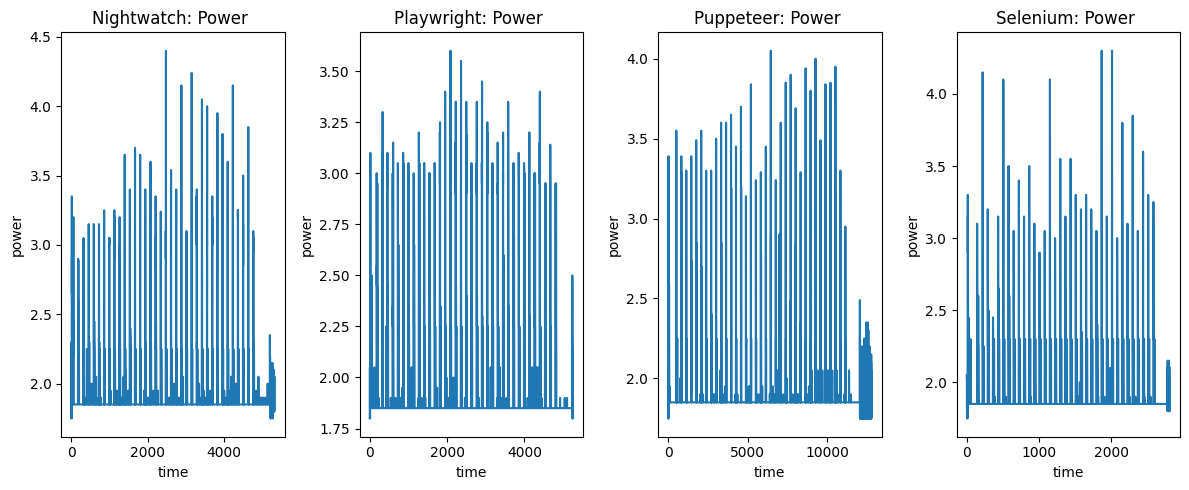

In [13]:
# Create subplots for Power
fig, axes = plt.subplots(nrows=1, ncols=len(all_dicts), figsize=(3*len(all_dicts), 5))

i = 0    
for ID in all_dicts:
    # print(i,all_dfs[i])
    # print(i,all_frameworks[i])
    # Plot each Power on a separate subplot
    sns.lineplot(data=all_dicts[ID]['df_power'], x='time', y='power', ax=axes[i])
    axes[i].set_title(all_dicts[ID]['id']+': Power ')
    i += 1
    
# Adjust layout
plt.tight_layout()
plt.show()

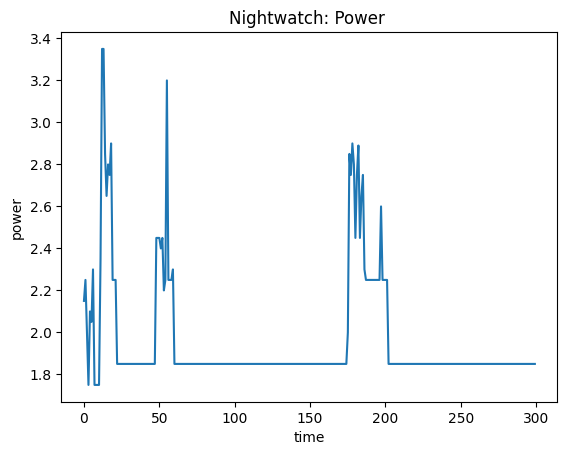

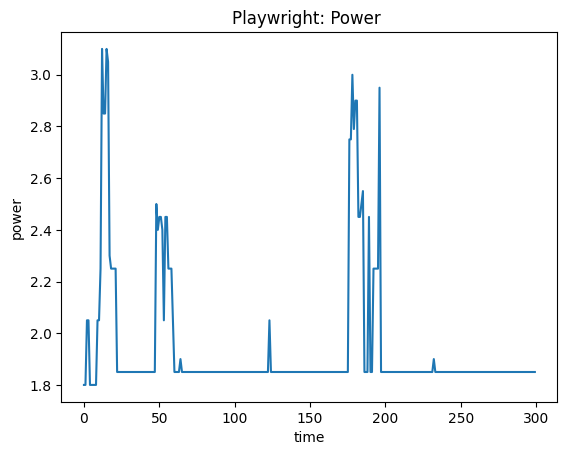

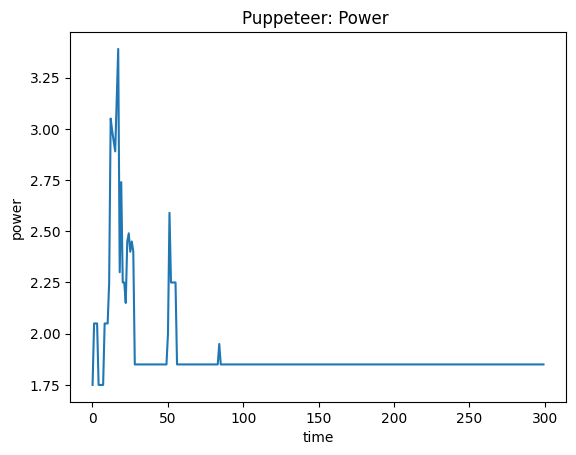

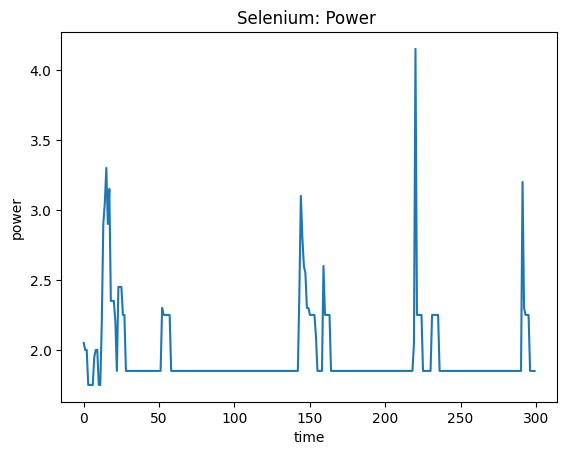

In [14]:
# Verify that the spike is done by 100
for ID in all_dicts:
    df1 = all_dicts[ID]['df_power']
    sns.lineplot(data=df1[(df1['time']<300)],x="time",y="power")
    plt.title(ID+': Power ')
    plt.show()

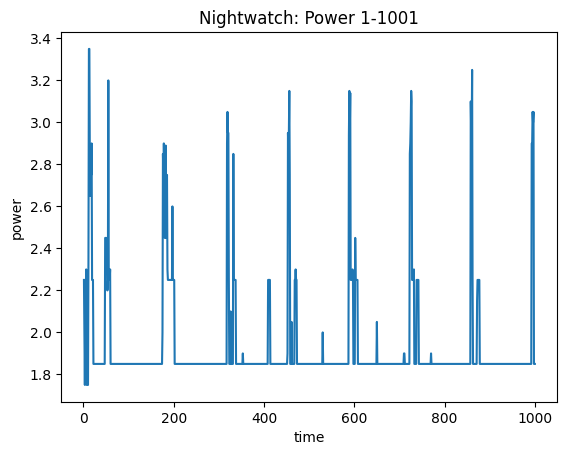

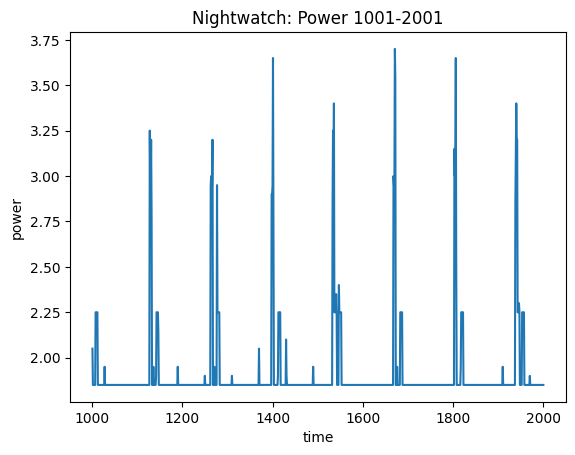

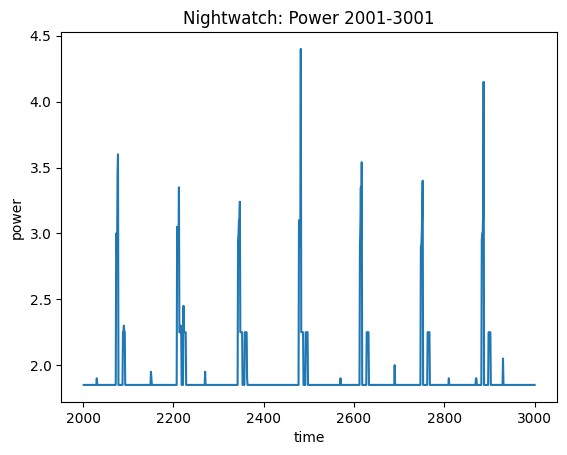

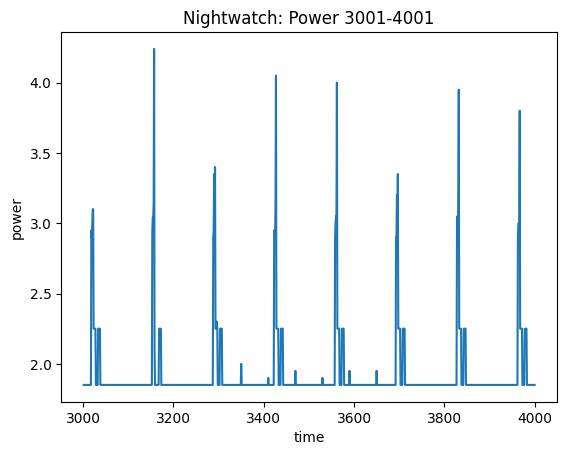

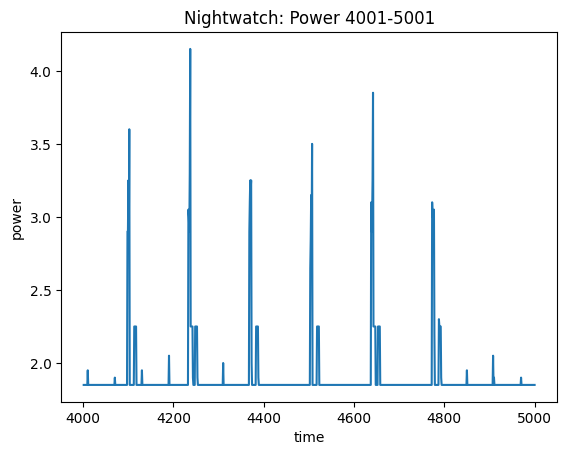

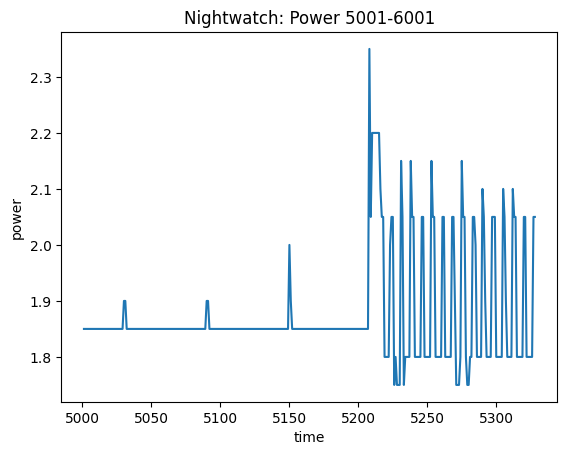

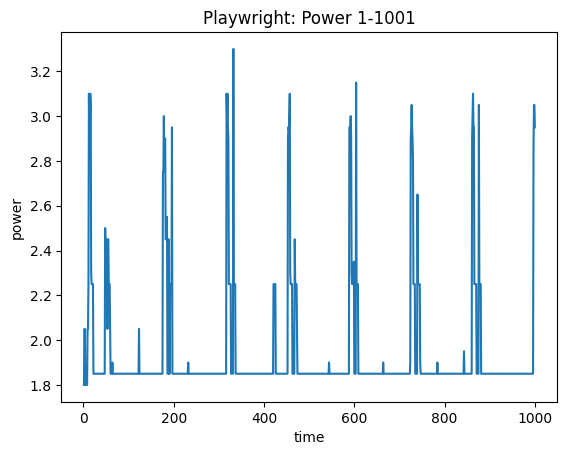

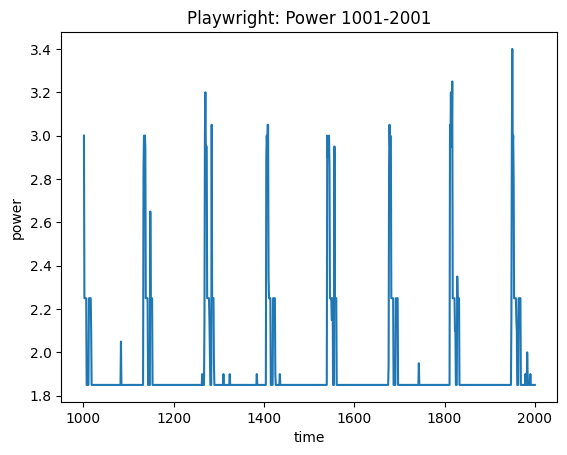

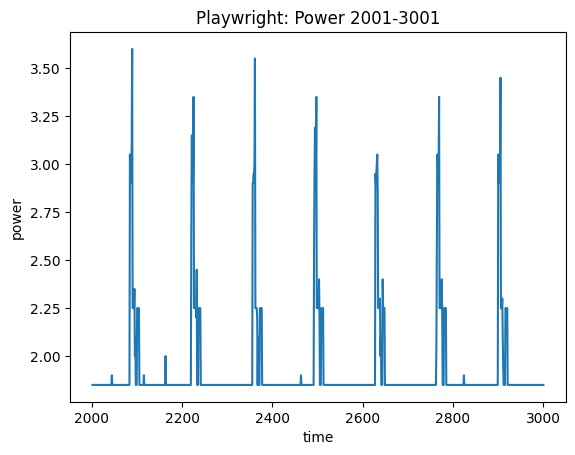

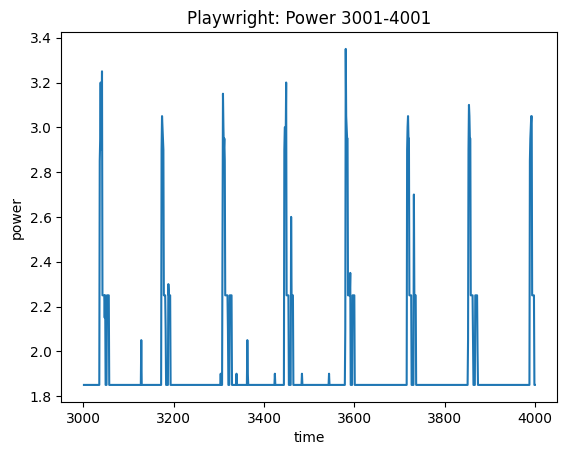

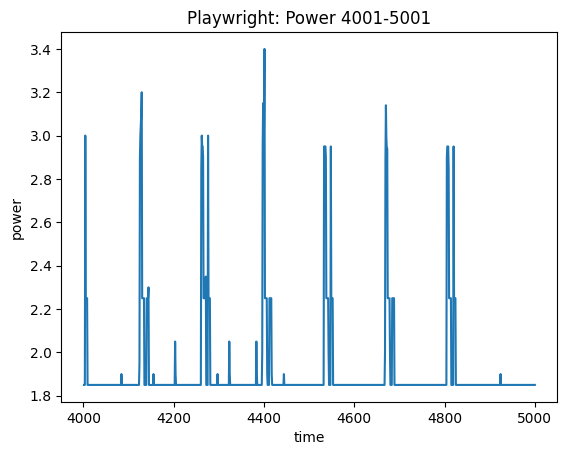

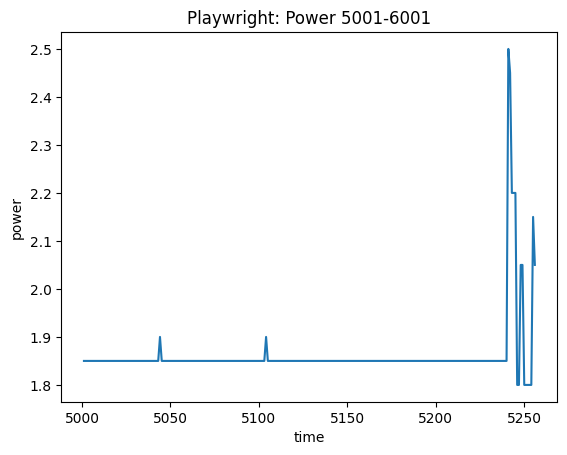

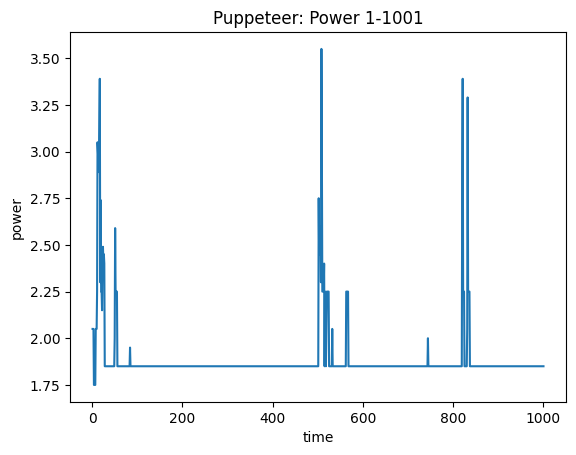

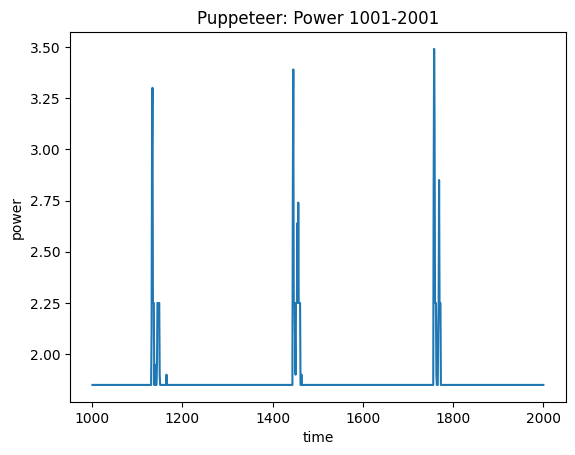

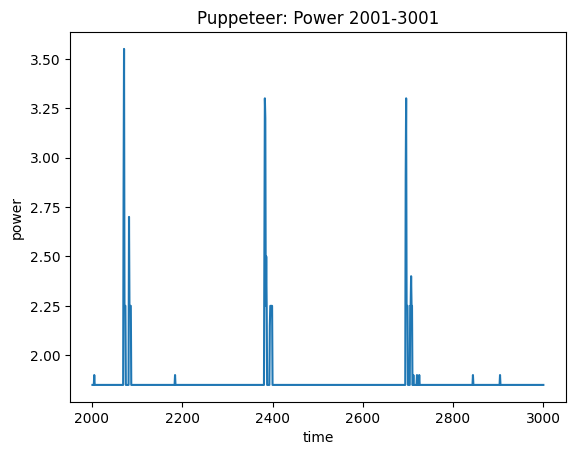

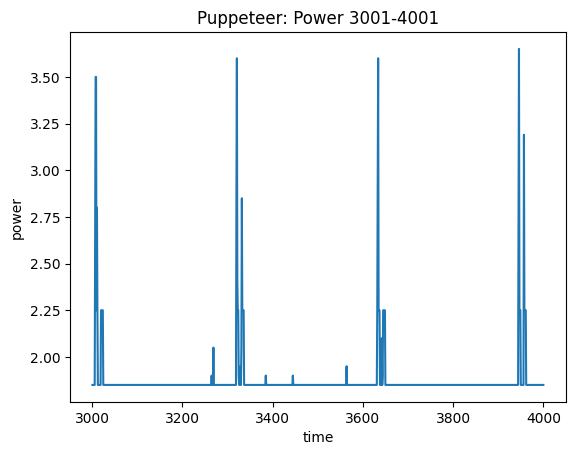

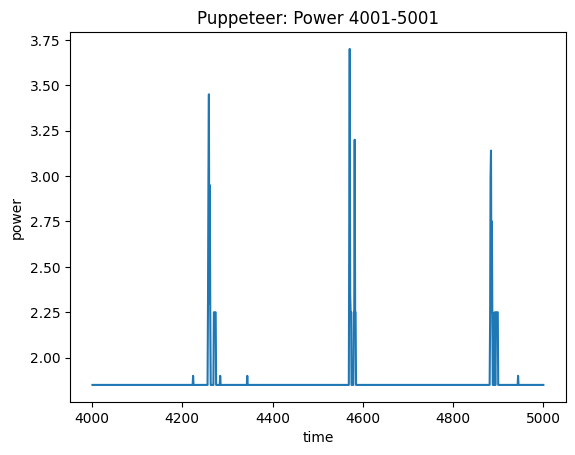

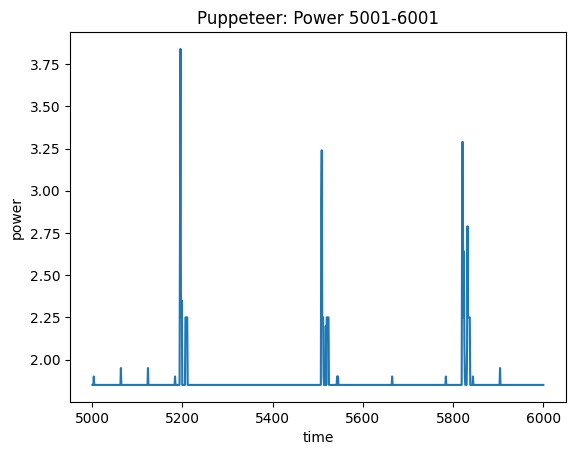

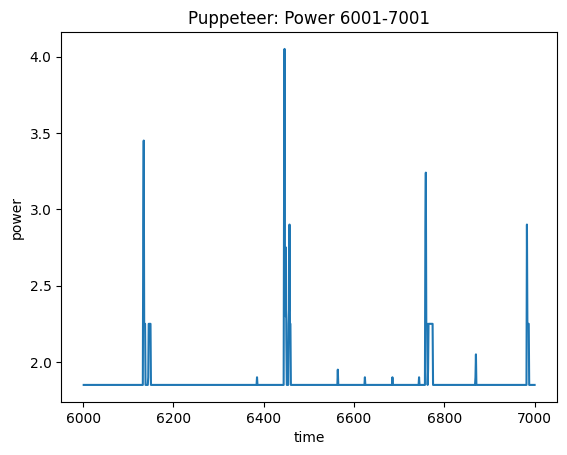

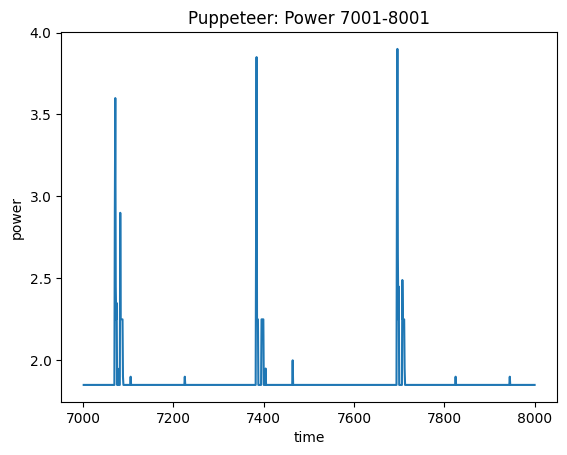

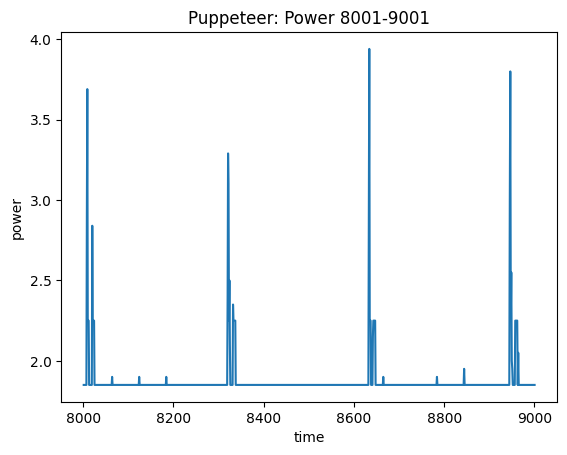

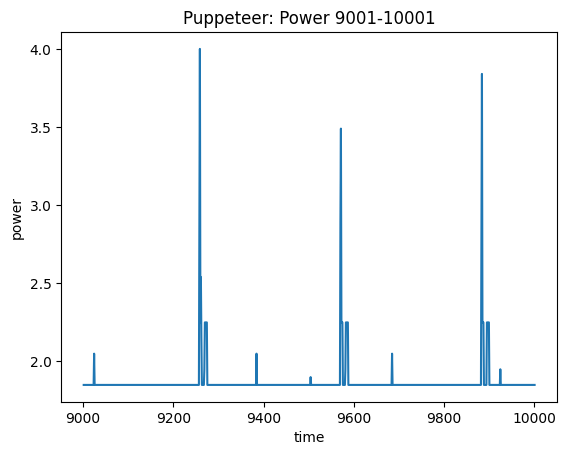

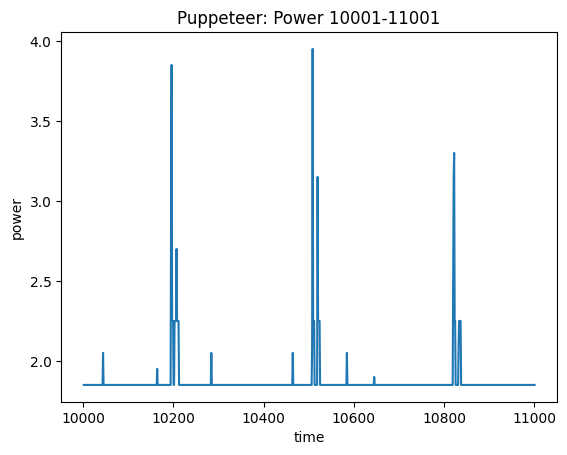

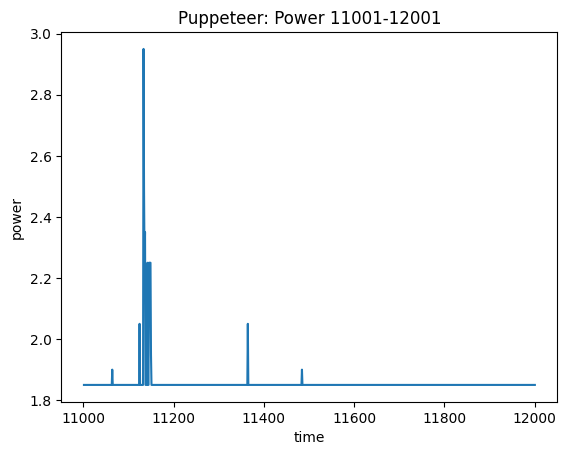

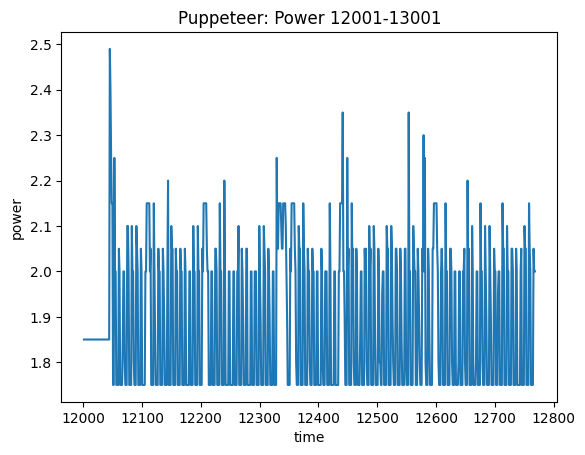

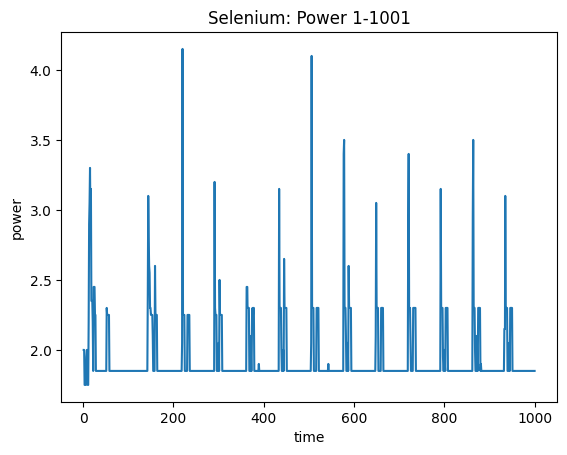

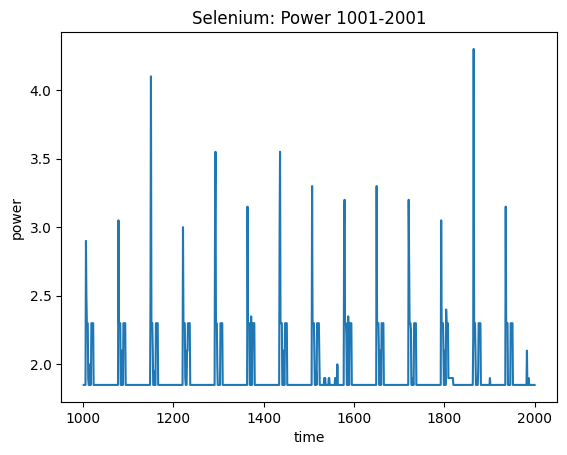

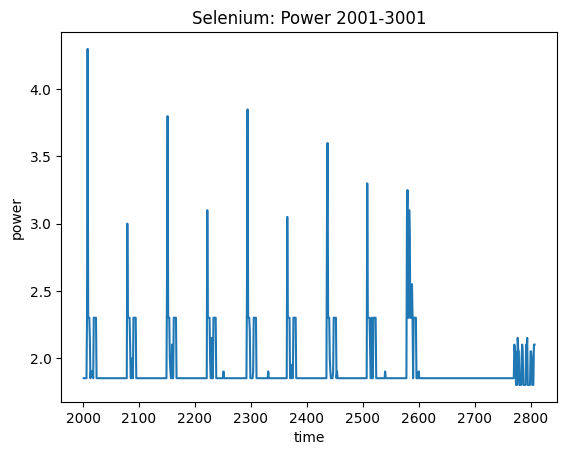

In [15]:
# Verify that the spike is done by 100
for ID in all_dicts:
    df1 = all_dicts[ID]['df_power']
    for i in range(1,len(df1),1000):
        sns.lineplot(data=df1[(df1['time']>i) &(df1['time']<i+1000)],x="time",y="power")
        plt.title(ID+': Power '+f'{i}-{i+1000}')
        plt.show()
        


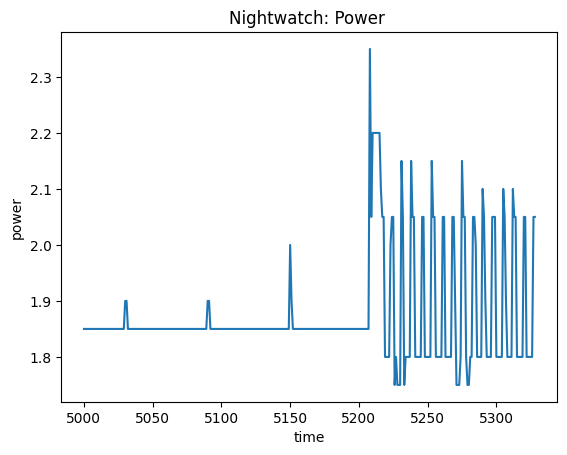

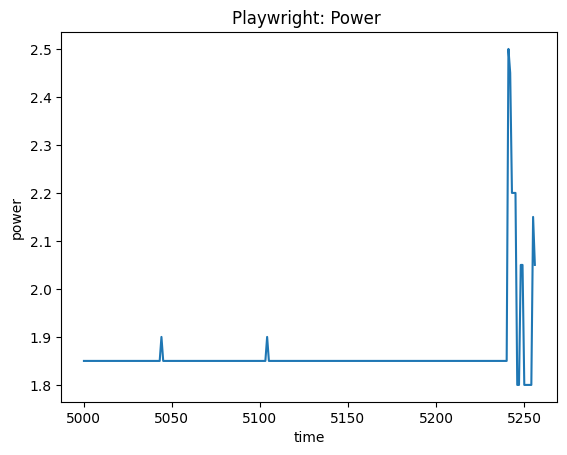

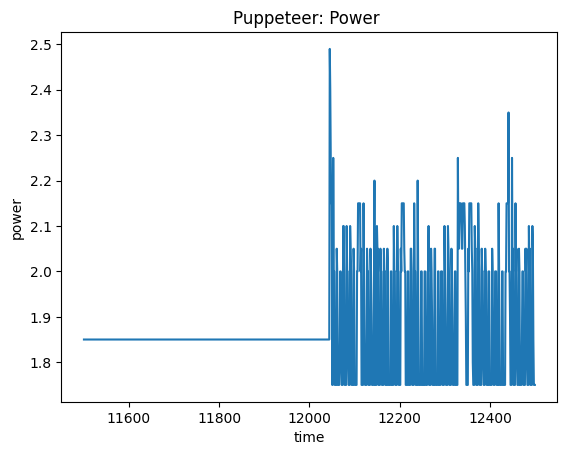

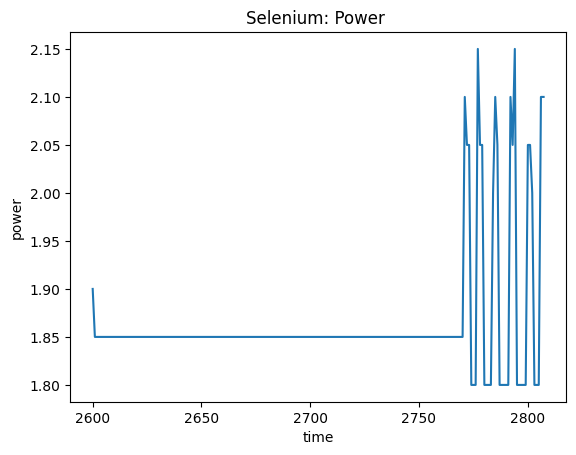

In [16]:

ID = 'Nightwatch'
df1 = all_dicts[ID]['df_power']
i = 5000
sns.lineplot(data=df1[(df1['time']>i) &(df1['time']<i+1000)],x="time",y="power")
plt.title(ID+': Power ')
plt.show()

ID = 'Playwright'
df1 = all_dicts[ID]['df_power']
i = 5000
sns.lineplot(data=df1[(df1['time']>i) &(df1['time']<i+1000)],x="time",y="power")
plt.title('Playwright'+': Power ')
plt.show()


ID = 'Puppeteer'
df1 = all_dicts[ID]['df_power']
i = 11500
sns.lineplot(data=df1[(df1['time']>i) &(df1['time']<i+1000)],x="time",y="power")
plt.title(ID+': Power ')
plt.show()

ID = 'Selenium'
df1 = all_dicts[ID]['df_power']
i = 2600
sns.lineplot(data=df1[(df1['time']>i) &(df1['time']<i+1000)],x="time",y="power")
plt.title(ID+': Power ')
plt.show()


In [17]:
# Manually update dictionary with end-times
all_dicts['Nightwatch']['end_time'] = 5000 # Nightwatch
all_dicts['Playwright']['end_time'] = 5000 # Playwright
all_dicts['Puppeteer']['end_time'] = 11500 # Puppeteer
all_dicts['Selenium']['end_time'] = 2600 # Selenium



In [18]:
# remove before spike and after last measurement
# all_dicts[0]['end_time'] = 11200 # Selenium
# all_dicts[1]['end_time'] = 7300 # Nightwatch



def remove_before_spike(dict_id):    
    df = all_dicts[dict_id]['df_power']
    spike_done = all_dicts[dict_id]['spike done']
    end_time = all_dicts[dict_id]['end_time']
    all_dicts[dict_id]['experiment_time'] = end_time - spike_done
    all_dicts[dict_id]['df_power'] = df[(df['time']>spike_done)&(df['time']<end_time)]

for ID in all_dicts:
    remove_before_spike(ID)
    


In [51]:
def find_threshold(framework_dict):
    df=framework_dict['df_power']
    name = framework_dict['name']
    print(name)
    BINS = 200
    # Step 1: Plot histogram of power values
    plt.figure(figsize=(10, 6))
    sns.histplot(df['power'], bins=BINS, kde=False)
    plt.xlabel('Power (W)')
    plt.ylabel('Frequency')
    plt.title(name+': Histogram of Power Measurements ')
    
    # Step 2: Create the histogram data
    hist, bin_edges = np.histogram(df['power'], bins=BINS)
    
    # the find_peaks skip the first hill, if it starts with a hill. Therefore, we insert a valley first. 
    hist_updated = np.insert(hist, 0, 0)
    
    # Step 3: Find local maxima (peaks)
    peaks, _ = find_peaks(hist_updated)
    print(peaks)
    
    max_peak = np.argmax(hist_updated)

    #sets the min range of the first bin - the sleep value
    sleep = bin_edges[max_peak-1]
    all_dicts[ID]['sleep'] = sleep

    # Step 4: Find local minima (valleys) by inverting the histogram
    minima, _ = find_peaks(-hist_updated)
    # Step 5: Find minima between each pair of consecutive maxima
    minima_between_peaks = []
    
    for i in range(len(peaks) - 1):
    #    # Find minima between peak i and peak i+1
        minima_in_range = [m for m in minima if peaks[i] < m < peaks[i + 1]]
        if minima_in_range:
            minima_between_peaks.append(minima_in_range[0])  # Append the first minima between the peaks

            
    # Step 5: Find the first minima after the max_peak
    # first_minima_after_max_peak_pos = None  # Initialize
    # for valley in minima:
    #    if valley > max_peak:  # Check if valley occurs after max_peak
    #        first_minima_after_max_peak_pos = valley
    #        break  # Stop after finding the first such valley
     
    # use the first local minimum:
    # local_minima_value = bin_edges[minima_between_peaks[0]]    
    
    #use the first minimum after the global maximum
    #first_minima_after_max_peak = bin_edges[first_minima_after_max_peak_pos]
    # Use the second minima
    
    # Step 5: Use the second minima
    second_minima_pos = minima[1] if len(minima) > 1 else None
    if second_minima_pos is None:
        raise ValueError("No second minima found.")


    
    second_minima_value = bin_edges[second_minima_pos]
    
    
    # Step 6: Plot the histogram curve
    plt.plot(bin_edges[:-1], hist, color='blue')

    # Mark the local maxima
    plt.plot(bin_edges[peaks], hist_updated[peaks], 'ro', label="Local Maxima")

    # Mark the local minima between peaks
    plt.plot(bin_edges[minima_between_peaks], hist[minima_between_peaks], 'go', label="Local Minima")

    # Step 7: Show the plot with annotations
    plt.legend(loc='upper right')
    plt.savefig(name+': histogram of power.png')
    plt.show()

    # Output the values of the minima and maxima
    print("Local Maxima (Power values):", bin_edges[peaks])
    print("Local Minima (Power values between peaks):", bin_edges[minima_between_peaks])

    # Visual confirmation of thresholds

    # Step 1: Plot the time series of power
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df[(df['time']>200)&(df['time']<2000)], x="time", y='power', label="Power over Time")

    # Convert the bin_edges for maxima and minima to actual power values
    
    

    
    # Step 3: Plot horizontal lines at the local minima values (in green)
    plt.axhline(y=second_minima_value, color='green', linestyle='--', label=f'Local Minima ({second_minima_value:.2f} W)')

    # Step 4: Show the plot with the horizontal lines for both maxima and minima
    plt.title(name+': Power over Time with threshold')
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.legend(loc='upper right')
    plt.savefig(name+': zoom of execution.png')
    plt.show()
    
    return sleep, second_minima_value


Nightwatch
[  1   4   8  12  16  20  24  28  32  36  40  44  48  51  59  63  71  75
  79  83  87  91  95  99 102 106 110 114 118 122 126 130 133 138 142 146
 153 157 165 169 173 181 188]


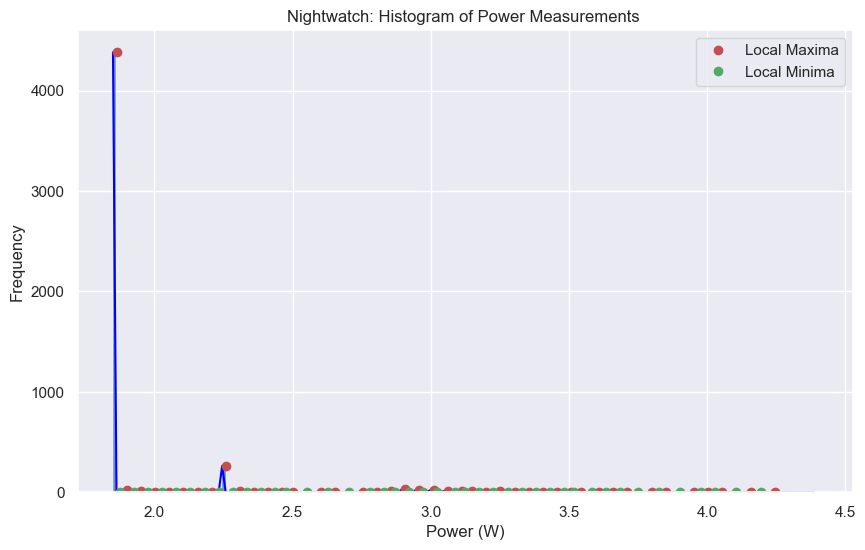

Local Maxima (Power values): [1.86275 1.901   1.952   2.003   2.054   2.105   2.156   2.207   2.258
 2.309   2.36    2.411   2.462   2.50025 2.60225 2.65325 2.75525 2.80625
 2.85725 2.90825 2.95925 3.01025 3.06125 3.11225 3.1505  3.2015  3.2525
 3.3035  3.3545  3.4055  3.4565  3.5075  3.54575 3.6095  3.6605  3.7115
 3.80075 3.85175 3.95375 4.00475 4.05575 4.15775 4.247  ]
Local Minima (Power values between peaks): [1.8755  1.9265  1.9775  2.0285  2.0795  2.1305  2.1815  2.2325  2.2835
 2.3345  2.3855  2.4365  2.47475 2.55125 2.62775 2.70425 2.78075 2.83175
 2.87    2.921   2.972   3.023   3.08675 3.125   3.176   3.227   3.278
 3.329   3.38    3.431   3.482   3.52025 3.584   3.635   3.686   3.74975
 3.82625 3.90275 3.97925 4.03025 4.10675 4.196  ]


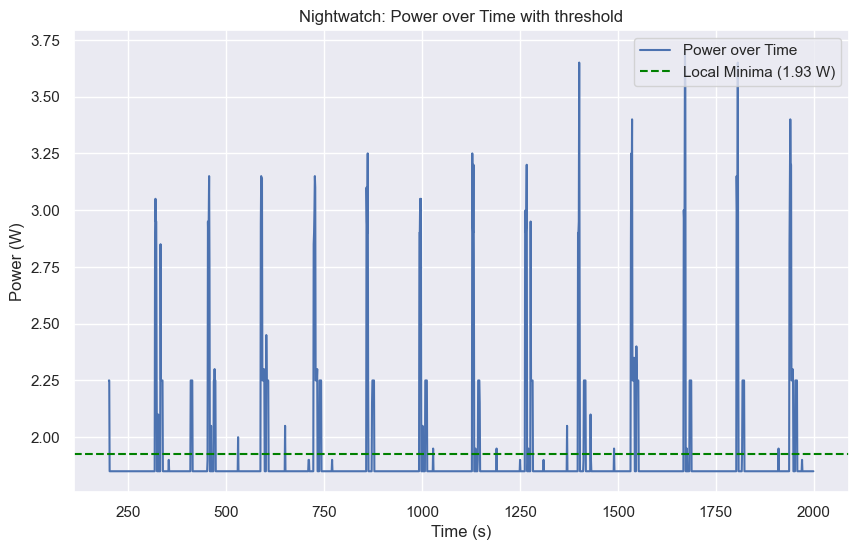

Playwright
[  1   6  12  18  23  29  35  41  46  52  58  63  69  75  80  86  92  98
 103 109 115 120 126 132 138 143 149 155 161 166 172 178 183 195]


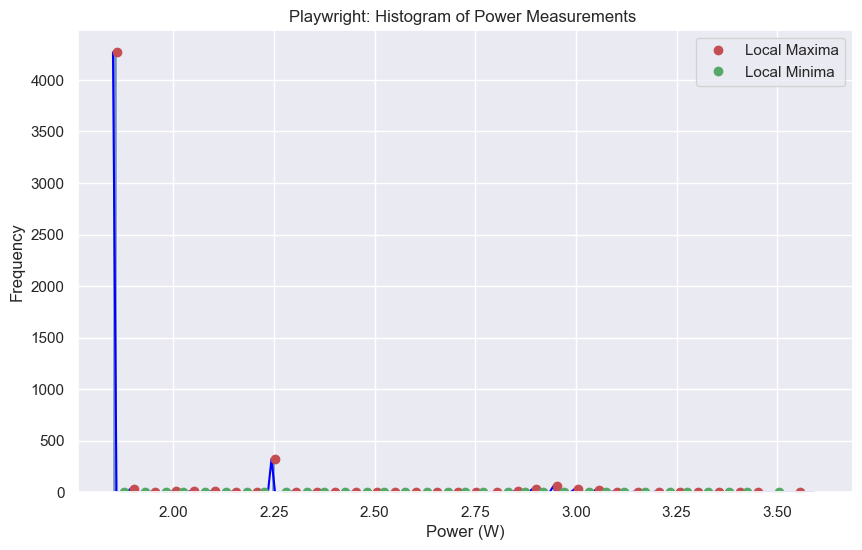

Local Maxima (Power values): [1.85875 1.9025  1.955   2.0075  2.05125 2.10375 2.15625 2.20875 2.2525
 2.305   2.3575  2.40125 2.45375 2.50625 2.55    2.6025  2.655   2.7075
 2.75125 2.80375 2.85625 2.9     2.9525  3.005   3.0575  3.10125 3.15375
 3.20625 3.25875 3.3025  3.355   3.4075  3.45125 3.55625]
Local Minima (Power values between peaks): [1.87625 1.92875 1.98125 2.025   2.0775  2.13    2.1825  2.22625 2.27875
 2.33125 2.375   2.4275  2.48    2.52375 2.57625 2.62875 2.68125 2.725
 2.76875 2.83    2.87375 2.9175  2.97    3.03125 3.075   3.11875 3.17125
 3.2325  3.27625 3.32875 3.38125 3.425   3.50375]


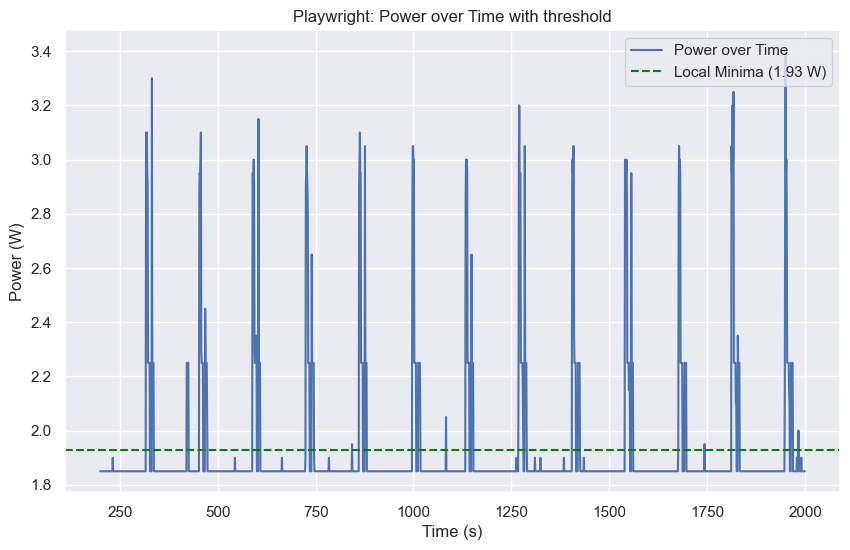

Puppeteer
[  1   5  10  14  19  23  28  32  37  41  46  51  55  60  63  69  72  78
  82  86  91  96 101 105 109 114 119 123 127 132 141 146 150 155 160 164
 168 178 181 187 191 196]


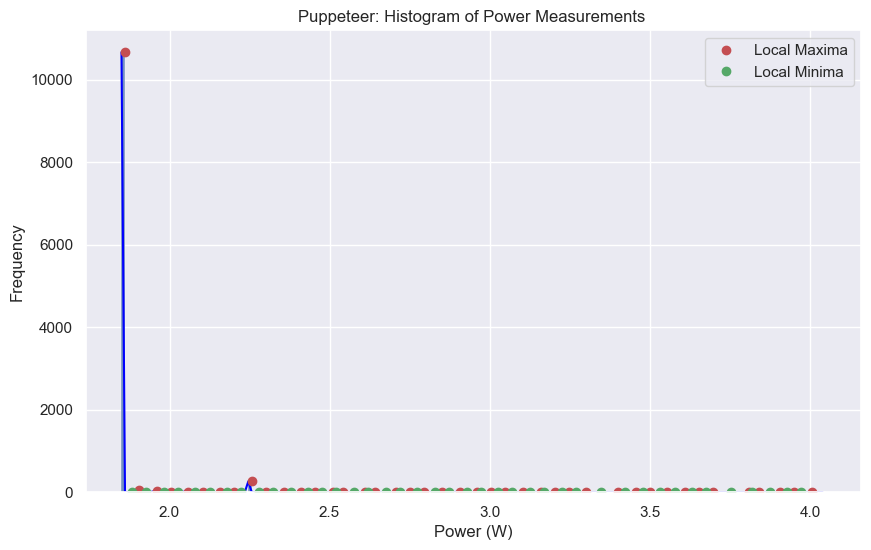

Local Maxima (Power values): [1.861 1.905 1.96  2.004 2.059 2.103 2.158 2.202 2.257 2.301 2.356 2.411
 2.455 2.51  2.543 2.609 2.642 2.708 2.752 2.796 2.851 2.906 2.961 3.005
 3.049 3.104 3.159 3.203 3.247 3.302 3.401 3.456 3.5   3.555 3.61  3.654
 3.698 3.808 3.841 3.907 3.951 4.006]
Local Minima (Power values between peaks): [1.883 1.927 1.982 2.026 2.081 2.125 2.18  2.224 2.279 2.323 2.378 2.433
 2.477 2.521 2.576 2.62  2.675 2.719 2.774 2.829 2.873 2.928 2.972 3.027
 3.071 3.126 3.17  3.225 3.269 3.346 3.423 3.478 3.533 3.577 3.632 3.676
 3.753 3.819 3.874 3.929 3.973]


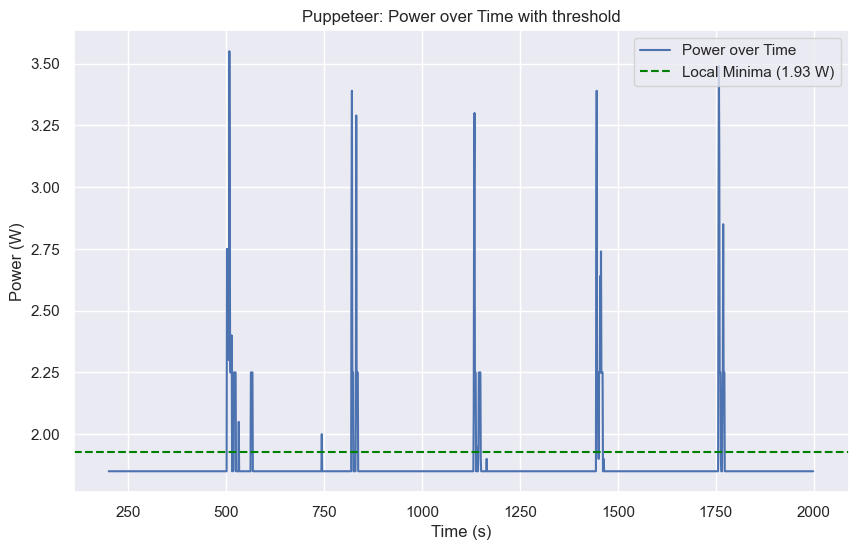

Selenium
[  1   5   9  13  17  21  25  29  33  37  41  45  49  54  58  62  66  74
  78  86  90  94  98 103 107 111 115 119 127 135 139 143 160 164 184 188]


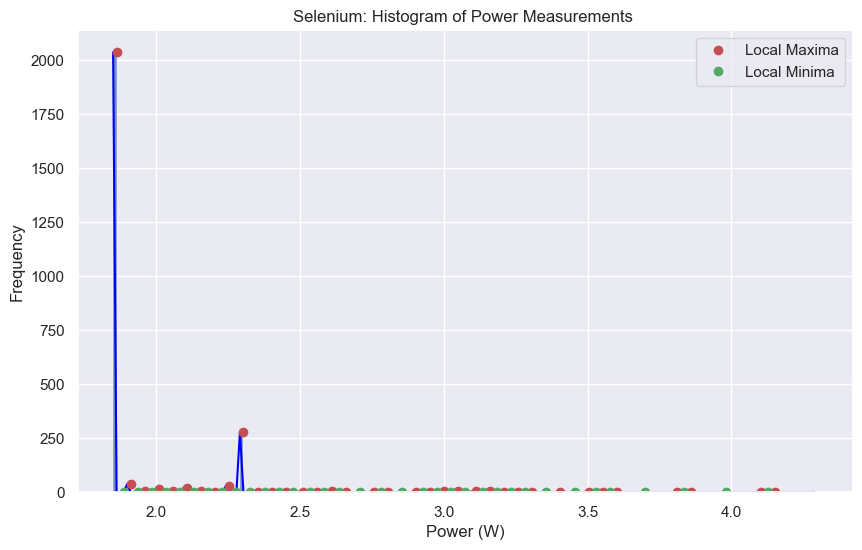

Local Maxima (Power values): [1.86225 1.91125 1.96025 2.00925 2.05825 2.10725 2.15625 2.20525 2.25425
 2.30325 2.35225 2.40125 2.45025 2.5115  2.5605  2.6095  2.6585  2.7565
 2.8055  2.9035  2.9525  3.0015  3.0505  3.11175 3.16075 3.20975 3.25875
 3.30775 3.40575 3.50375 3.55275 3.60175 3.81    3.859   4.104   4.153  ]
Local Minima (Power values between peaks): [1.88675 1.93575 1.98475 2.03375 2.08275 2.13175 2.18075 2.22975 2.27875
 2.32775 2.37675 2.42575 2.47475 2.536   2.585   2.634   2.7075  2.781
 2.8545  2.928   2.977   3.026   3.075   3.13625 3.18525 3.23425 3.28325
 3.35675 3.45475 3.52825 3.57725 3.69975 3.8345  3.9815  4.1285 ]


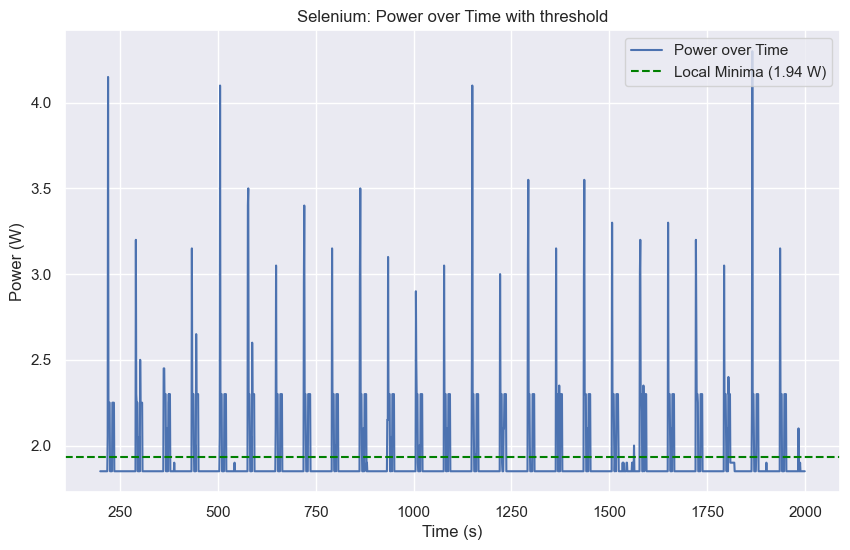

In [52]:
#threshold_list = []
for ID in all_dicts:
    #threshold_list.append(find_threshold(all_dicts[i]))
    all_dicts[ID]['sleep'], all_dicts[ID]['threshold']=find_threshold(all_dicts[ID])


In [56]:
df_list = []

for ID in all_dicts:

    time = all_dicts[ID]['experiment_time']
    power_sleep = all_dicts[ID]['sleep']
    df = all_dicts[ID]['df_power']
    df['power_without_sleep'] = df['power'] - power_sleep
    energy_for_run_without_sleep = np.trapezoid(df['power_without_sleep'],df['time'])
    energy_idle =  energy_for_run_without_sleep / 35

    #sleep_consumption_sleep = power_sleep * time
    #power_sum = sum(all_dicts[ID]['df_power']['power'])
    # overhead_idle_2 = power_sum - sleep_consumption_sleep

    #all_dicts[ID]['sleep_consumption_mode'] = all_dicts[ID]['df_power']['power'].mode() * all_dicts[ID]['experiment_time']
    #all_dicts[ID]['sleep_consumption2'] = all_dicts[ID]['sleep'] * all_dicts[ID]['experiment_time']
    #all_dicts[ID]['power_sum'] = sum(all_dicts[ID]['df_power']['power'])
    #all_dicts[ID]['overhead_idle_mode'] =  all_dicts[ID]['power_sum'] - all_dicts[ID]['sleep_consumption_mode']
    #all_dicts[ID]['overhead_idle2'] =  all_dicts[ID]['power_sum'] - all_dicts[ID]['sleep_consumption2']

    print(ID)
    #print('df_power', all_dicts[ID]['df_power'])
    #print('power_sum', power_sum)
    print('power sleep', power_sleep)
    print('energy_idle',energy_idle)
    all_dicts[ID]['energy_idle'] = energy_idle
    #print('experiment_time', time)
    #print('sleep_consumption', sleep_consumption_sleep)
    #print('overhead_',ID, ': ', overhead_idle_2)

    # ID, power_sleep, energy_idle
    df_list.append((ID, power_sleep, energy_idle))
    


    # 
df_energy_idle = pd.DataFrame(df_list,columns=['ID','power_sleep','energy_idle'])  
    



Nightwatch
power sleep 1.85
energy_idle 9.675489285714326
Playwright
power sleep 1.85
energy_idle 10.929004142857154
Puppeteer
power sleep 1.85
energy_idle 7.489883571428581
Selenium
power sleep 1.85
energy_idle 6.512637857142857


/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_58507/1345142417.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['power_without_sleep'] = df['power'] - power_sleep


In [57]:
df_energy_idle

,ID,power_sleep,energy_idle
0,Nightwatch,1.85,9.675489
1,Playwright,1.85,10.929004
2,Puppeteer,1.85,7.489884
3,Selenium,1.85,6.512638


In [58]:
df_energy_idle.to_csv("../Results/firstResults/energyidle_calculated.csv",index=False)